In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add project root directory to path to allow importing from src/
sys.path.append("..")
from src.data import load_raw_dataset

# Configuration
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# Load a 50,000 row sample for fast interactive EDA (Remove nrows=50000 for full dataset)
df = load_raw_dataset(data_dir="../data/raw", split="train", nrows=50000)

print(f"\nDataset Shape: {df.shape[0]:,} rows | {df.shape[1]} columns")
df.head()

Loading train_transaction.csv...
Loading train_identity.csv...
Performing left join on TransactionID...
Optimizing memory footprint...
Memory usage decreased to 88.45 MB (46.6% reduction)

Dataset Shape: 50,000 rows | 434 columns


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


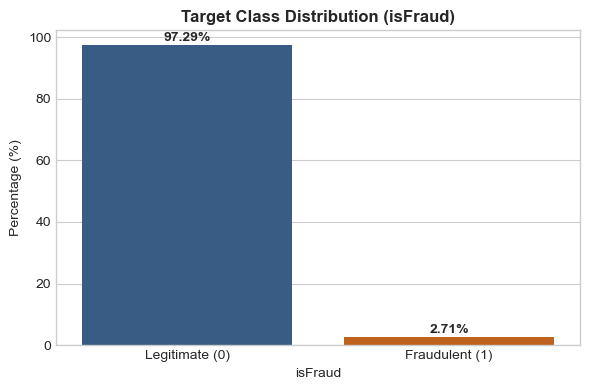

In [6]:
target_counts = df['isFraud'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#2b5c8f', '#d95f02'], ax=ax)

ax.set_title("Target Class Distribution (isFraud)", fontsize=12, fontweight='bold')
ax.set_xticklabels(['Legitimate (0)', 'Fraudulent (1)'])
ax.set_ylabel("Percentage (%)")

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

Total columns with missing values: 359 / 434


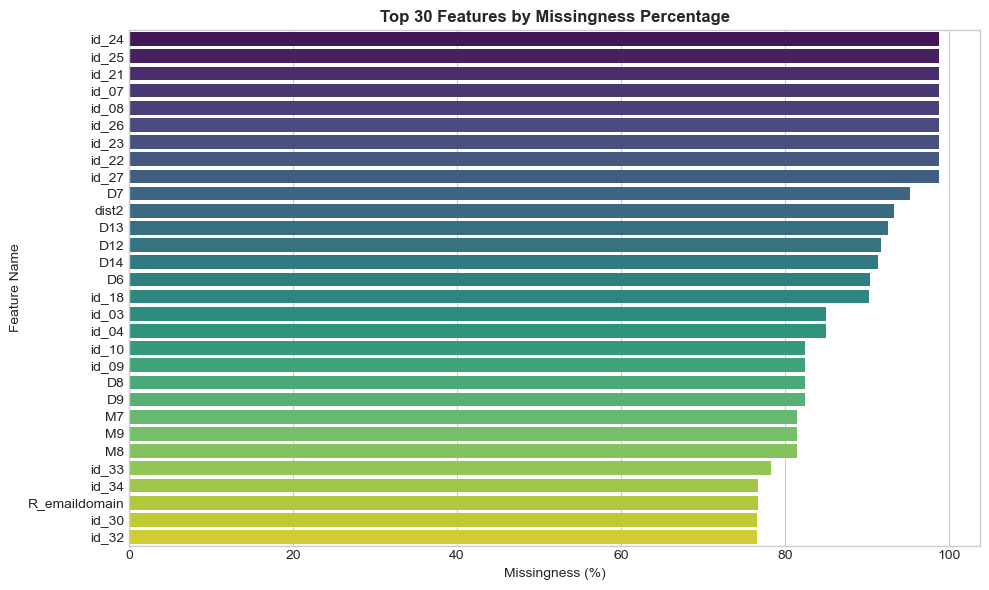

In [7]:
# Calculate missing value percentages
missing_series = df.isnull().mean() * 100
missing_df = missing_series.reset_index()
missing_df.columns = ['Feature', 'MissingPercent']
missing_df = missing_df.sort_values(by='MissingPercent', ascending=False)

# Filter features with missing values
missing_df_filtered = missing_df[missing_df['MissingPercent'] > 0]

print(f"Total columns with missing values: {len(missing_df_filtered)} / {df.shape[1]}")

# Plot top 30 missing features
plt.figure(figsize=(10, 6))
sns.barplot(data=missing_df_filtered.head(30), x='MissingPercent', y='Feature', palette='viridis')
plt.title("Top 30 Features by Missingness Percentage", fontsize=12, fontweight='bold')
plt.xlabel("Missingness (%)")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

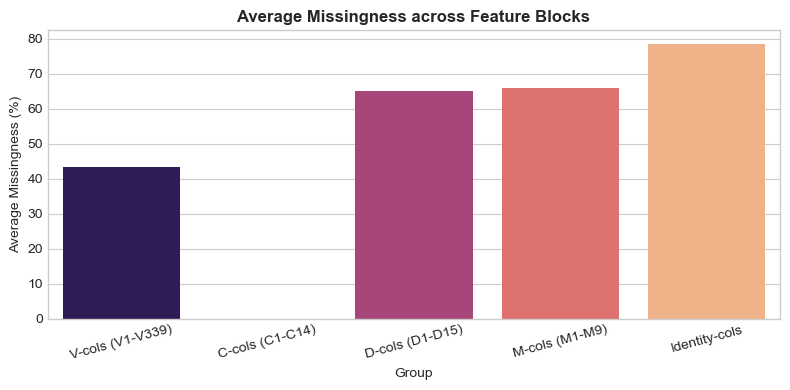

In [8]:
# Group missingness analysis by IEEE-CIS feature blocks (V, C, D, M, id)
feature_groups = {
    'V-cols (V1-V339)': [c for c in df.columns if c.startswith('V')],
    'C-cols (C1-C14)': [c for c in df.columns if c.startswith('C')],
    'D-cols (D1-D15)': [c for c in df.columns if c.startswith('D')],
    'M-cols (M1-M9)': [c for c in df.columns if c.startswith('M')],
    'Identity-cols': [c for c in df.columns if c.startswith('id_') or c in ['DeviceType', 'DeviceInfo']]
}

group_missing = []
for group_name, cols in feature_groups.items():
    if cols:
        avg_missing = df[cols].isnull().mean().mean() * 100
        group_missing.append({'Group': group_name, 'AvgMissingPercent': avg_missing})

group_df = pd.DataFrame(group_missing)

plt.figure(figsize=(8, 4))
sns.barplot(data=group_df, x='Group', y='AvgMissingPercent', palette='magma')
plt.title("Average Missingness across Feature Blocks", fontsize=12, fontweight='bold')
plt.ylabel("Average Missingness (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [9]:
c_cols = [c for c in df.columns if c.startswith('C')]
print(df[c_cols].isnull().sum())

C1     0
C2     0
C3     0
C4     0
C5     0
C6     0
C7     0
C8     0
C9     0
C10    0
C11    0
C12    0
C13    0
C14    0
dtype: int64
